# F2 12Q VQE: Circuit Compression Demo

This notebook demonstrates VQE under `gradient_method="parameter-shift"` with hybrid MPS/MPO circuit compression.

Comparison items:
- Baseline: no compression
- Compression: suffix block planning + local recompression

In [1]:
# from __future__ import annotations

import os
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Work around duplicated OpenMP runtime loading on Windows notebook kernels.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner
from quantum_hw.algorithms.circuit_compression import plan_hybrid_suffix_blocks
from quantum_hw.circuit import QuantumCircuit

In [ ]:
# ===== 1) Load F2 12-qubit Hamiltonian =====
json_path = Path('../data/f2_R2.6_angstrom_sto-3g_12q.json')
data = json.loads(json_path.read_text(encoding='utf-8'))

f2_constant = float(data['constant'])
f2_12q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
nqubits = int(data['nqubits'])
fci_energy = float(data['fci_energy'])

print('Loaded:', json_path)
print('nqubits =', nqubits, 'term_count =', len(f2_12q_terms))
print('fci_energy =', fci_energy)

Loaded: data\chemistry\f2_R2.6_angstrom_sto-3g_12q.json
nqubits = 12 term_count = 382
fci_energy = -195.9734686096283


In [3]:
# ===== 2) Build the same LiH custom ansatz style used in existing demo =====
def build_f2_symbolic_ansatz() -> QuantumCircuit:
    qc = QuantumCircuit(12)

    # HF state or "singlet" reference state
    qc.ry("theta_0", 8)
    qc.cx(8, 9)
    qc.cx(9, 10)
    qc.cx(10, 11)

    for q in range(10):
        qc.x(q)

    qc.pauli_evolution("theta_1", "Y0 X1 Z2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 X10 Y11")
    qc.pauli_evolution("theta_2", "Y2 X3 Z4 Z5 Z6 Z7 Z8 Z9 X10 Y11")
    qc.pauli_evolution("theta_3", "Y4 X5 Z6 Z7 Z8 Z9 X10 Y11")
    qc.pauli_evolution("theta_4", "Y6 X7 Z8 Z9 X10 Y11")
    qc.pauli_evolution("theta_5", "Y8 X9 X10 Y11")

    return qc


custom_ansatz_qc = build_f2_symbolic_ansatz()
symbolic_params = sorted([
    k for k, v in custom_ansatz_qc.params_value.items()
    if isinstance(k, str) and isinstance(v, str)
])

print('custom gate count =', len(custom_ansatz_qc.gates))
print('symbolic params =', symbolic_params)

custom gate count = 149
symbolic params = ['theta_0', 'theta_1', 'theta_2', 'theta_3', 'theta_4', 'theta_5']


In [4]:
# ===== 3) Shared VQE config (parameter-shift) =====
cfg = {
    'layers': 3,
    'shots': 1024,
    'max_iters': 10,
    'learning_rate': 0.2,
    'seed': 7,
    'gradient_method': 'autograd',
    'prefer_chips': 'Simulator',
    'shift': math.pi / 2.0,
}

base_kwargs = {
    'name': 'f2_12q_custom_compress_demo',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': f2_12q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_ansatz_qc,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01] * len(symbolic_params),
    'target_qubits': list(range(1, nqubits+1)),
}

print(cfg)

{'layers': 3, 'shots': 1024, 'max_iters': 10, 'learning_rate': 0.2, 'seed': 7, 'gradient_method': 'autograd', 'prefer_chips': 'Simulator', 'shift': 1.5707963267948966}


In [5]:
# ===== 4) Baseline run: no compression =====
runner_base = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
    enable_circuit_compression=False,
)

res_base = runner_base.run_model(**base_kwargs)
e_total_base = f2_constant + res_base.best_energy
err_base = abs(e_total_base - fci_energy)

print('Baseline best_total =', round(e_total_base, 8))
print('Baseline abs_error_vs_fci =', round(err_base, 8))

[vqe] prepare run: name=f2_12q_custom_compress_demo num_qubits=12 model=custom layers=3 shots=1024 max_iters=10
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=10 layers=3 params=6 ansatz=custom shots=1024 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=-5.620472 grad_norm=0.392761
[vqe] iter 0 new best energy=-5.620472
[vqe] iter 1 start
[vqe] iter 1 energy=-5.670816 grad_norm=0.383714
[vqe] iter 1 new best energy=-5.670816
[vqe] iter 2 start
[vqe] iter 2 energy=-5.769930 grad_norm=0.354465
[vqe] iter 2 new best energy=-5.769930
[vqe] iter 3 start
[vqe] iter 3 energy=-5.828485 grad_norm=0.319129
[vqe] iter 3 new best energy=-5.828485
[vqe] iter 4 start
[vqe] iter 4 energy=-5.873118 grad_norm=0.298975
[vqe] iter 4 new best energy=-5.873118
[vqe] iter 5 start
[vqe] iter 5 energy=-5.933159 grad_norm=0.226693
[vqe] iter 5 new best energy=-5.933159
[vqe] iter 6 start
[vqe] iter 6 energy=-5.970465 grad_n

In [ ]:
# ===== 5) Compression run: enable planner + compression =====
cfg['gradient_method'] = "parameter-shift"
runner_cmp = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
    enable_circuit_compression=True,
    compression_block_layers=6,
)

res_cmp = runner_cmp.run_model(**base_kwargs)
e_total_cmp = f2_constant + res_cmp.best_energy
err_cmp = abs(e_total_cmp - fci_energy)

print('Compressed best_total =', round(e_total_cmp, 8))
print('Compressed abs_error_vs_fci =', round(err_cmp, 8))

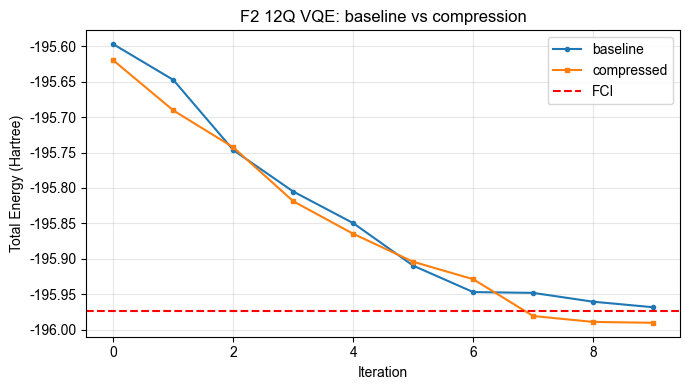

--- Summary ---
Baseline total energy   : -195.96840422
Compressed total energy : -195.9903876
Baseline |E-FCI|        : 0.00506439
Compressed |E-FCI|      : 0.01691899


In [16]:
# ===== 6) Compare convergence curves =====
plt.figure(figsize=(7, 4))
plt.plot(np.array(res_base.energy_history) + f2_constant, marker='o', ms=3, label='baseline')
plt.plot(np.array(res_cmp.energy_history) + f2_constant, marker='s', ms=3, label='compressed')
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI')
plt.xlabel('Iteration')
plt.ylabel('Total Energy (Hartree)')
plt.title('F2 12Q VQE: baseline vs compression')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('--- Summary ---')
print('Baseline total energy   :', round(e_total_base, 8))
print('Compressed total energy :', round(e_total_cmp, 8))
print('Baseline |E-FCI|        :', round(err_base, 8))
print('Compressed |E-FCI|      :', round(err_cmp, 8))

In [6]:
# ===== 7) Run experiments =====
cfg['prefer_chips'] = 'Baihua'
cfg['zne'] = True
cfg['readout_mitigation'] = True
cfg['clifford_fitting'] = True
cfg['clifford_fitting_num_samples'] = 8
cfg['gradient_method'] = "parameter-shift"
runner_cmp = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    zne=cfg['zne'],
    readout_mitigation=cfg['readout_mitigation'],
    shift=cfg['shift'],
    # clifford_fitting=cfg['clifford_fitting'],
    # clifford_fitting_num_samples=cfg['clifford_fitting_num_samples'],
    enable_circuit_compression=True,
    compression_block_layers=6,
)

exp_kwargs = {
    'name': 'f2_12q_custom_compress_demo',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': f2_12q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_ansatz_qc,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01] * len(symbolic_params),
}

res_cmp = runner_cmp.run_model(**exp_kwargs)
e_total_cmp = f2_constant + res_cmp.best_energy
err_cmp = abs(e_total_cmp - fci_energy)

print('=== 12-Qubit F2 VQE Result ===')
print('Compressed best_total =', round(e_total_cmp, 8))
print('Compressed abs_error_vs_fci =', round(err_cmp, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res_cmp.energy_history) + f2_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'F2 VQE Convergence (R=2.6)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[vqe] prepare run: name=f2_12q_custom_compress_demo num_qubits=12 model=custom layers=3 shots=1024 max_iters=10
Baihua configuration loading done!
The last calibration time was 2026-03-19 10:35:13
[vqe] candidate chips: ['Baihua']
Baihua configuration loading done!
The last calibration time was 2026-03-19 10:35:13
[vqe] running on chip: Baihua
[vqe] start optimization: iters=10 layers=3 params=6 ansatz=custom shots=1024 shift=1.5707963267948966 gradient=parameter-shift
[vqe] iter 0 start


KeyboardInterrupt: 